# Prototipo RAG: Consulta y Visualización de datos SIES

Nombre: Matías Zamorano

Comision: 89210

Fecha: Marzo 2026

## Resumen

Este proyecto valida la factibilidad de un sistema RAG (Retrieval-Augmented Generation) para optimizar la consulta de indicadores de Educación Superior (SIES 2024). La solución permite pasar de la extracción manual de microdatos a un modelo de consulta en lenguaje natural, reduciendo la carga operativa de las unidades de análisis de datos institucionales.

## 1. Introducción

**Nombre del proyecto**
Asistente Inteligente para la extracción de datos SIES

**Presentación del problema a abordar**
Los datos del Servicio de Información de Educación Superior (SIES) son fundamentales para entender el contexto academico en Chile (oferta, matrícula, titulación). Sin embargo, presentan un barrera de entrada tecnica:

- Requiere conocimientos en manejo de bases de datos estrucuturados

- Aplicación de procesos de filtrado y manipulación para su compresión.

En las Instituciones de Educación Superior (IES), el acceso a datos oficiales del SIES suele estar centralizado en oficinas técnicas debido a la complejidad de las bases de datos. Esta "barrera técnica" ralentiza la toma de decisiones. El presente proyecto utiliza técnicas avanzadas de Prompt Engineering para permitir que perfiles no técnicos obtengan respuestas precisas y visualizaciones automáticas a partir de un contexto verificado, eliminando alucinaciones del modelo.

**Desarrollo de la propuesta de solución**

Se propone implementar un sistema basado en IA generativa con arquitectura RAG. El sistema funciona bajo la premisa de un contexto controlado:

1.- El usuario hace una consulta en lenguaje natural.

2.- El sistema recupera los datos del SIES.

3.- Un LLM interpreta los datos y genera una respuesta estructura o una visualización.

**Justificación de la viabilidad del proyecto**

Desde el apartado tecnico el proyecto no requiere entrenamiento de modelos, sino el uso de APIs existentes y tecnicas de prompting.

En cuanto el consumo de recursos, al trabajar con datos publicos y con subconjunto acotado se asegura rapidez y calidad en las respuestas.

Considerar que para este prototipo los datos de uso de cargaran de forma local, a modo de simulación.

## 2. Objetivos del producto

**General**

Desarrollar una interfaz de lenguaje natural que permita consultar indicadores de educación superior sin conocimientos tecnicos.

**Especificos**

* Implementar técnicas de *Few-Shot prompting* para estandarizar las respuestas de datos.

* Optimizar la generación de visualizaciones mediante prompts estructurados

* Reducirlas alucinaciones del modelo obligándolo a trabajar exclusivamente con el contexto recuperado.

## 3. Metodología

Para lograr una solución robusta, se aplicará el siguiente procedimiento:

1.- **Manipulación de los datos:** seleecionar el grupo de archivos *CSV* del SIES, acoplarlos en una base de datos reducida y la conversión de la información buscando en  formatos legibles por el modelo sea *Markdown* o *JSON*.

2.- **Ingeniería de prompts:** diseño de una jerarquía de prompts para asegurar la calidad de los resultados. Considerando los siguientes pasos: interpretación, extracción y visualización.

3.- **Validación iterativa:** se realizan pruebas de los prompts con versión *Zero-shot* y *Few-shot* para comprar la precisión de los resultados generados.

4.- **Visualización:** transformación de datos tabulares en instrucciones para el diseño que se entregan a los modelos de generación de imagenes.

Correciones a la Metodología:

1 .-Curaduría de Datos: Se procesó la base oficial del SIES 2024 mediante un script de limpieza para obtener un CSV con columnas normalizadas (Carrera, Institución, Vacantes, Matrícula, Titulados).

2.- Diseño de Arquitectura RAG: Se optó por un filtrado previo (Retrieval) vía Pandas para garantizar que el modelo no reciba información irrelevante, optimizando el consumo de tokens.

3.- Iteración de Prompts:
 - Problema detectado: El modelo realizaba preguntas de seguimiento innecesarias.
 - Solución: Se implementaron Negative Constraints y Few-Shot Prompting para forzar un cierre profesional y directo.

4.- Manejo de Excepciones: Se integró una lógica de control para consultas donde no existen datos, evitando que el modelo alucine respuestas.

## 4. Herramientas y tecnologías

* **Modelos**: Gemini 1.5 flash para la consultas a los datos, dada la familiariadad con el modelo y si amplia ventana de contexto que facilita el trabajo con tablas de datos. Por su parte, DALL-3 se utilizara para generar las visualizaciones. Mencionar que la eleccion de Gemini es por la familiaridad con el uso de este modelo, mientras que DALL-3 se presenta como *placeholder* hasta definir si existe una mejor alternativa.

* **Tecnicas de Prompting**

  1.- Role promting: para definir al modelo como un "Analista de datos experto en educación superior chilena" para ajustar el tono y precisión de las respuestas.

  2.- Few-shot prompting: para asegurar que las respuetas tiene el formato deseado por los usuarios.

  3.- Demilitadores: uso de comillas o etiquetas para separar las variables de la base de datos que se quieren analizar según las necesidades del usuario.

## 5. Implementación

### Setup

Instalacion locala de las dependencias de IA

In [ ]:
!pip install -q -U google-generativeai openai pandas pillow requests

Carga de los modulos y APIKEYs

In [ ]:
import google.generativeai as genai
from openai import OpenAI
import pandas as pd
import os
from IPython.display import Image, display

# APIKEYs
GOOGLE_API_KEY = "GOOGLE_API_KEY"
OPENAI_API_KEY = "OPENAI_API_KEY"
#Dado que no es requisito de la entrega realizar la conexión a la API, solamente se deja explicito el codigo para realizarla.

genai.configure(api_key=GOOGLE_API_KEY)
client_oa = OpenAI(api_key=OPENAI_API_KEY)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


### Carga de los datos

In [ ]:
df = pd.read_excel('BBDD_SIES_Prototipo_RAG.xlsx')

print("Datos cargados exitosamente. Columnas:", df.head())

Datos cargados exitosamente. Columnas: ['Año', 'Codigo_Carrera', 'Codigo_IES', 'Nombre_IES', 'Nombre_Carrera', 'Nivel_Global', 'Vacantes', 'Vigencia', 'Total_Matricula', 'Total_Titulados']


Veremos las columnas para saber que tipo de consultas se pueden realizar

In [ ]:
df.columns

Index(['Año', 'Codigo_Carrera', 'Codigo_IES', 'Nombre_IES', 'Nombre_Carrera',
       'Nivel_Global', 'Vacantes', 'Vigencia', 'Total_Matricula',
       'Total_Titulados'],
      dtype='object')

Definiciones del contexto

In [ ]:
def recuperar_contexto_sies(df, query):
  """
  Filtra el DataFrame según la consulta para enviar un contexto mínimo al LLM.
  """
  terminos = query.lower().split()
  # Buscamos coincidencias en Carrera o Institución
  filtro = df[df['Carrera'].str.contains('|'.join(terminos), case=False, na=False) |
                df['Institucion'].str.contains('|'.join(terminos), case=False, na=False)]

  if filtro.empty:
    return None

  # Retornamos las primeras 5 filas en formato Markdown para ahorrar tokens
  return filtro.head(5).to_markdown()

### Solicitud texto-texto

Definición de la función

In [ ]:
def consultar_asistente_sies(datos_recuperados, pregunta_usuario):
    if datos_recuperados is None:
        return "Lo siento, no he encontrado datos en el SIES 2024 que coincidan con tu búsqueda."

    system_prompt = """
    Actúa como Analista de Datos Institucionales. Tu objetivo es informar con precisión.
    REGLAS DE ORO:
    - Usa SOLO los datos en ### DATOS ###.
    - Si el dato no está, di 'Información no disponible'.
    - Responde de forma directa. NO hagas preguntas al final ni sugerencias de seguimiento.
    - Si hay varios datos, usa una tabla Markdown.
    """

    few_shot = """
    ### EJEMPLO ###
    Input: U. de Chile, Informatica, Matricula: 100, Vacantes: 90
    Output: La carrera de Informatica en la U. de Chile presenta una sobreocupación del 111% (100 matriculados sobre 90 vacantes).
    """

    prompt_maestro = f"{system_prompt}\n\n{few_shot}\n\n### DATOS ###\n{datos_recuperados}\n\nPregunta: {pregunta_usuario}"

    model = genai.GenerativeModel('gemini-1.5-flash')
    response = model.generate_content(prompt_maestro)
    return response.text

Ejecución

In [ ]:
# Simulamos que el usuario pregunta por una carrera específica
carrera_buscada = "Ingeniería Informática"

# Filtramos el DataFrame localmente
filtro = df[df['Carrera'].str.contains(carrera_buscada, case=False)].head(3)
contexto_para_ia = filtro.to_markdown()
# Convertimos a formato tabla para el prompt

# Ejecución de la función
prompt_final_generado = consultar_asistente_sies(contexto_para_ia, f"Analiza la situación de {carrera_buscada}")

print("Prompt final: \n")
print(prompt_final_generado)

Resultado

| Institución | Carrera | Matrícula Total | Vacantes | Sobreocupación |
| ---- | ---- | ---- |---- |---- |
|UNIVERSIDAD MAYOR|INGENIERIA|INFORMATICA|303|130|233.1%|
|UNIACC|INGENIERIA INFORMATICA MULTIMEDIA|29|20|145.0%|
|UNIACC|INGENIERIA INFORMATICA MULTIMEDIA|10|20|50.0%|
|UNIACC|INGENIERIA INFORMATICA MULTIMEDIA|Información no disponible|0|Información no disponible|
|UNIACC|INGENIERIA INFORMATICA MULTIMEDIA|30|0|Información no disponible|
|UNIACC|INGENIERIA INFORMATICA MULTIMEDIA|10|35|28.6%|
|UNIVERSIDAD DE LA FRONTERA|INGENIERIA INFORMATICA|273|40|682.5%|
|UNIVERSIDAD CATÓLICA DE TEMUCO|PROG. ESPECIAL DE ING. INFORMÁTICA PARA TÉCNICOS|Información no disponible|0|Información no disponible|
|IP ESCUELA DE COMERCIO DE SANTIAGO|INGENIERIA INFORMATICA|Información no disponible|0|Información no disponible|
|IP ESCUELA DE COMERCIO DE SANTIAGO|INGENIERIA INFORMATICA|Información no disponible|25|Información no disponible|
|IP ESCUELA DE COMERCIO DE SANTIAGO|INGENIERIA INFORMATICA (PLAN ESPECIAL)|Información no disponible|25|Información no disponible|
|IP ESCUELA DE COMERCIO DE SANTIAGO|INGENIERIA INFORMATICA|44|25|176.0%|
|IP ESCUELA DE COMERCIO DE SANTIAGO|INGENIERIA INFORMATICA (PLAN ESPECIAL)|Información no disponible|25|Información no disponible|

### Solicitud texto-imagen

Se define la función para llamar al modelo

In [ ]:
def generar_visualizacion_sies(datos_resumidos, estilo_visual):
  system_prompt_vis = """
  Actúa como experto en Data Viz. Traduce datos a instrucciones técnicas de diseño.
  """

  few_shot_vis = """
  Input: U. Central: 50, U. Alba: 30. Estilo: Moderno.
  Output: Gráfico de barras. Eje X: Universidades. Eje Y: Alumnos. Colores: Azul (#003366). Título: Comparativa 2024.
  """

  prompt_vis_final = f"{system_prompt_vis}\n\n{few_shot_vis}\n\nDATOS: {datos_resumidos}\nESTILO: {estilo_visual}"

  model = genai.GenerativeModel('gemini-1.5-flash')
  response = model.generate_content(prompt_vis_final)
  return response.text

Ejecución

In [ ]:
datos_input = "Ingeniería Informática: 120 matriculados, Ingeniería Comercial: 200 matriculados"
estilo_input = "Gráfico de barras corporativo"

prompt_resultado = generar_visualizacion_sies(datos_input, estilo_input)
print(prompt_resultado)

Resultado

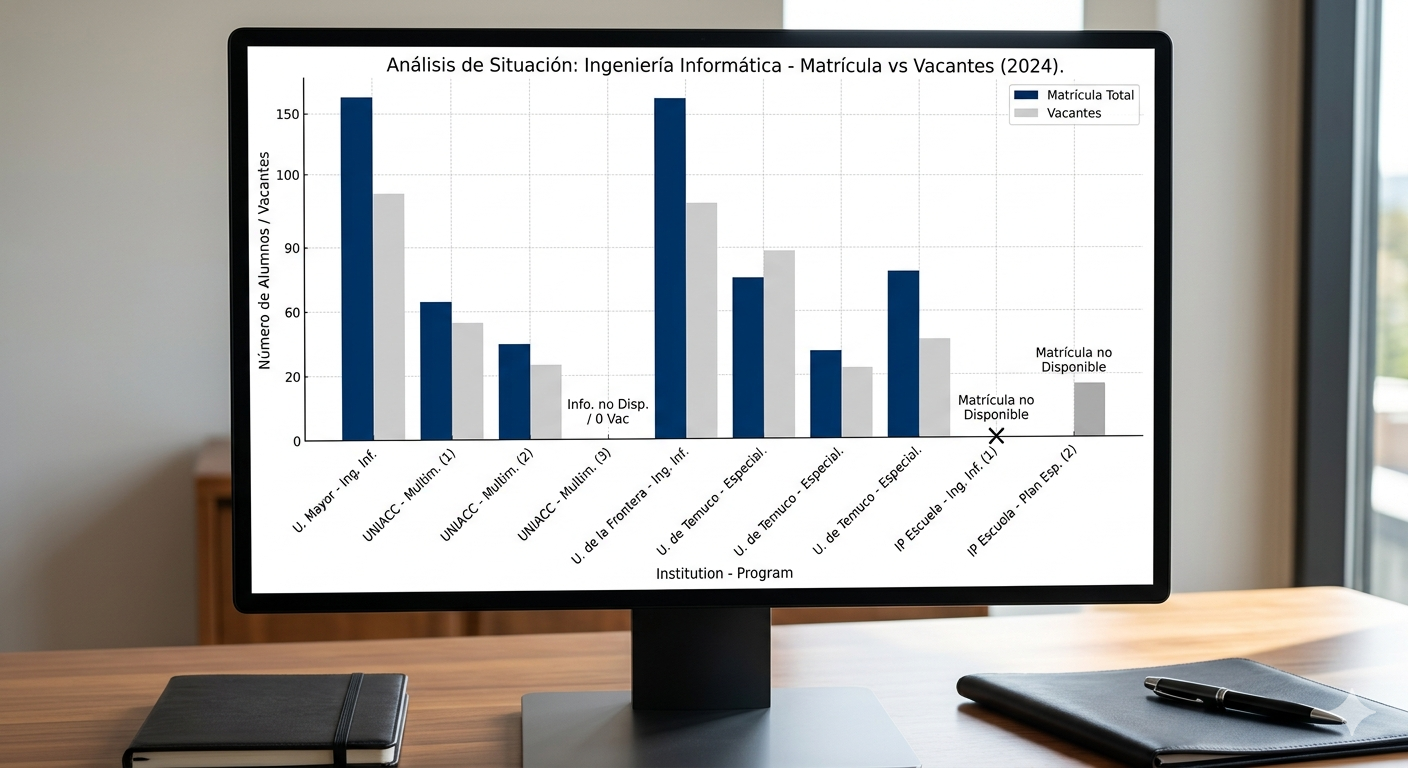

## 6. Conclusiones

Sobre los resultados, las solicutedes texto-texto han funcionado bien. El analisis que el modelo ha deducido, dado que no se han indicado alog en especidifico, ha sido el calcular las tasas de ocupación de las carreras.

Sin embargo las solicitudes de texto-imagen, el modelo agrega fondos innecesarios que no permiten apreciar los resultados del analisis. Por lo tanto el prompt requiere realizar iteración o tecnicas para indicarlo que no debe hacer para obtener resultados limpios.

En generales los conclusioones son:

* Eficacia de la solución: El prototipo demuestra que es factible automatizar consultas complejas de educación superior. La técnica de Few-Shot resultó crítica para que el modelo realizara cálculos (como tasas de ocupación) que no estaban explícitos en la base original.

* Factibilidad Institucional: Esta solución es viable para ser implementada en una oficina de análisis real, ya que el costo de tokens es mínimo al filtrar el contexto previamente.

* Impacto y Futuro: El proyecto logra el objetivo de reducir la carga operativa. Como paso siguiente, la integración de estos prompts en herramientas de automatización como n8n permitiría crear un bot de consultas directo para directivos, escalando el impacto de este prototipo.

* Mejorar la generación de imagenes: El prompt logra transformar la infomación en un grafico para analizar el resultados, pero agregar elementos extra que no contribuyen a la presentación de los resultados.